# Estudo de Machine Learning - Falencia de Empresas


## Introducao

O problema deste projeto e prever se uma empresa ira falir ou nao, com base em indicadores financeiros presentes no dataset. A variavel de interesse e a coluna `Bankrupt?`, em que cada registro representa uma empresa classificada como falida (`1`) ou nao falida (`0`).

Esse problema e de classificacao supervisionada porque ja existe uma variavel alvo conhecida no conjunto de dados, indicando o resultado correto para cada empresa. O modelo aprende a partir de exemplos rotulados, relacionando os atributos financeiros de entrada com a classe final da empresa. Como a saida possui duas categorias, `0` e `1`, trata-se de uma classificacao binaria supervisionada.


## 1. Importacoes e carregamento dos dados

Nesta etapa, vamos importar as bibliotecas principais e carregar o arquivo `archive/data.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.options.display.float_format = '{:.4f}'.format
sns.set_theme(style='whitegrid')

caminho_dados = 'archive/data.csv'
df = pd.read_csv(caminho_dados)
random_state = 42


## 2. Conhecimento inicial da base

Aqui vamos olhar a estrutura geral da base e confirmar a variavel alvo.


In [2]:
display(df.head())
print(f'Shape da base: {df.shape}')


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.3706,0.4244,0.4057,0.6015,0.6015,0.9990,0.7969,0.8088,0.3026,...,0.7168,0.0092,0.6229,0.6015,0.8279,0.2902,0.0266,0.5641,1,0.0165
1,1,0.4643,0.5382,0.5167,0.6102,0.6102,0.9989,0.7974,0.8093,0.3036,...,0.7953,0.0083,0.6237,0.6102,0.8400,0.2838,0.2646,0.5702,1,0.0208
2,1,0.4261,0.4990,0.4723,0.6015,0.6014,0.9989,0.7964,0.8084,0.3020,...,0.7747,0.0400,0.6238,0.6014,0.8368,0.2902,0.0266,0.5637,1,0.0165
3,1,0.3998,0.4513,0.4577,0.5835,0.5835,0.9987,0.7970,0.8090,0.3033,...,0.7396,0.0033,0.6229,0.5835,0.8347,0.2817,0.0267,0.5647,1,0.0240
4,1,0.4650,0.5384,0.5223,0.5988,0.5988,0.9990,0.7974,0.8093,0.3035,...,0.7950,0.0039,0.6235,0.5988,0.8400,0.2785,0.0248,0.5756,1,0.0355


Shape da base: (6819, 96)


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [4]:
estatisticas_descritivas = df.describe()

for inicio in range(0, len(estatisticas_descritivas.columns), 12):
    display(estatisticas_descritivas.iloc[:, inicio:inicio + 12])


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0323,0.5052,0.5586,0.5536,0.6079,0.6079,0.9988,0.7972,0.8091,0.3036,0.7814,1995347312.8029
std,0.1767,0.0607,0.0656,0.0616,0.0169,0.0169,0.0130,0.0129,0.0136,0.0112,0.0127,3237683890.5225
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.4765,0.5355,0.5273,0.6004,0.6004,0.9990,0.7974,0.8093,0.3035,0.7816,0.0002
50%,0.0000,0.5027,0.5598,0.5523,0.6060,0.6060,0.9990,0.7975,0.8094,0.3035,0.7816,0.0003
75%,0.0000,0.5356,0.5892,0.5841,0.6139,0.6138,0.9991,0.7976,0.8095,0.3036,0.7817,4145000000.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,9990000000.0000


,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥)
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,1950427306.0568,0.4674,16448012.9059,0.1150,0.1907,0.1906,0.1907,0.2288,0.3235,1328640.6021,0.1091,0.1844
std,2598291553.9983,0.0170,108275033.5328,0.1387,0.0334,0.0335,0.0335,0.0333,0.0176,51707089.7679,0.0279,0.0332
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0001,0.4616,0.0002,0.0000,0.1736,0.1736,0.1737,0.2147,0.3177,0.0156,0.0961,0.1704
50%,509000000.0000,0.4651,0.0003,0.0735,0.1844,0.1844,0.1844,0.2245,0.3225,0.0274,0.1042,0.1797
75%,3450000000.0000,0.4710,0.0005,0.2058,0.1996,0.1996,0.1996,0.2388,0.3286,0.0464,0.1162,0.1935
max,9980000000.0000,1.0000,990000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,3020000000.0000,1.0000,1.0000


,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0224,0.8480,0.6891,0.6892,0.2176,5508096595.2487,1566212.0552,0.2642,0.3797,403284.9542,8376594.8197,0.6310
std,0.0121,0.0108,0.0139,0.0139,0.0101,2897717771.1697,114159389.5183,0.0096,0.0207,33302155.8255,244684748.4469,0.0112
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0221,0.8480,0.6893,0.6893,0.2176,4860000000.0000,0.0004,0.2638,0.3747,0.0076,0.0047,0.6306
50%,0.0221,0.8480,0.6894,0.6894,0.2176,6400000000.0000,0.0005,0.2640,0.3804,0.0106,0.0074,0.6307
75%,0.0222,0.8481,0.6896,0.6896,0.2176,7390000000.0000,0.0005,0.2644,0.3867,0.0163,0.0122,0.6311
max,1.0000,1.0000,1.0000,1.0000,1.0000,9990000000.0000,9330000000.0000,1.0000,1.0000,2750000000.0000,9230000000.0000,1.0000


,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,4416336.7143,0.1132,0.8868,0.0088,0.3747,0.0060,0.1090,0.1827,0.4025,0.1416,12789705.2376,9826220.8612
std,168406905.2815,0.0539,0.0539,0.0282,0.0163,0.0122,0.0278,0.0308,0.0133,0.1011,278259836.9841,256358895.7053
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0030,0.0729,0.8512,0.0052,0.3702,0.0054,0.0961,0.1694,0.3974,0.0765,0.0007,0.0044
50%,0.0055,0.1114,0.8886,0.0057,0.3726,0.0054,0.1041,0.1785,0.4001,0.1184,0.0010,0.0066
75%,0.0093,0.1488,0.9271,0.0068,0.3763,0.0058,0.1159,0.1916,0.4046,0.1769,0.0015,0.0090
max,9940000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,9740000000.0000,9730000000.0000


,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,2149106056.6076,1008595981.8175,0.0386,2325854.2664,0.4007,11255785.3217,0.8141,0.4001,0.5223,0.1241,3592902.1968,37159994.1471
std,3247967014.0479,2477557316.9202,0.0367,136632654.3899,0.0327,294506294.1168,0.0591,0.2020,0.2181,0.1393,171620908.6068,510350903.1627
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0002,0.0002,0.0218,0.0104,0.3924,0.0041,0.7743,0.2420,0.3528,0.0335,0.0052,0.0020
50%,0.0008,0.0006,0.0295,0.0186,0.3959,0.0078,0.8103,0.3865,0.5148,0.0749,0.0079,0.0049
75%,4620000000.0000,0.0037,0.0429,0.0359,0.4019,0.0150,0.8504,0.5406,0.6891,0.1611,0.0130,0.0128
max,9990000000.0000,9990000000.0000,1.0000,8810000000.0000,1.0000,9570000000.0000,1.0000,1.0000,1.0000,1.0000,8820000000.0000,9650000000.0000


,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0907,0.3538,0.2774,55806804.5258,0.7616,0.7358,0.3314,54160038.1359,0.9347,0.0025,0.0292,1195855763.3089
std,0.0503,0.0351,0.0105,582051554.6194,0.2067,0.0117,0.0135,570270621.9592,0.0256,0.0121,0.0271,2821161238.2625
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0533,0.3410,0.2770,0.0032,0.6270,0.7336,0.3281,0.0000,0.9311,0.0022,0.0146,0.0001
50%,0.0827,0.3486,0.2772,0.0065,0.8069,0.7360,0.3297,0.0020,0.9377,0.0023,0.0227,0.0002
75%,0.1195,0.3609,0.2774,0.0111,0.9420,0.7386,0.3323,0.0090,0.9448,0.0025,0.0359,0.0005
max,1.0000,1.0000,1.0000,9910000000.0000,1.0000,1.0000,1.0000,9540000000.0000,1.0000,1.0000,1.0000,10000000000.0000


,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,2163735272.0344,0.5940,2471976967.4443,0.6715,1220120.5016,0.7616,0.3314,0.1156,0.6497,0.4618,0.5934,0.3156
std,3374944402.1661,0.0090,2938623226.6788,0.0093,100754158.7132,0.2067,0.0135,0.0195,0.0474,0.0299,0.0586,0.0130
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0001,0.5939,0.0003,0.6716,0.0854,0.6270,0.3281,0.1109,0.6333,0.4571,0.5660,0.3130
50%,0.0002,0.5940,1080000000.0000,0.6716,0.1969,0.8069,0.3297,0.1123,0.6454,0.4598,0.5933,0.3150
75%,4900000000.0000,0.5940,4510000000.0000,0.6716,0.3722,0.9420,0.3323,0.1171,0.6631,0.4642,0.6248,0.3177
max,10000000000.0000,1.0000,10000000000.0000,1.0000,8320000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000,6819.0000
mean,0.0315,0.0012,0.8078,18629417.8118,0.6239,0.6079,0.8404,0.2804,0.0275,0.5654,1.0000,0.0476
std,0.0308,0.0342,0.0403,376450059.7458,0.0123,0.0169,0.0145,0.0145,0.0157,0.0132,0.0000,0.0500
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
25%,0.0180,0.0000,0.7967,0.0009,0.6236,0.6004,0.8401,0.2769,0.0268,0.5652,1.0000,0.0245
50%,0.0276,0.0000,0.8106,0.0021,0.6239,0.6060,0.8412,0.2788,0.0268,0.5653,1.0000,0.0338
75%,0.0384,0.0000,0.8265,0.0053,0.6242,0.6139,0.8424,0.2814,0.0269,0.5657,1.0000,0.0528
max,1.0000,1.0000,1.0000,9820000000.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [5]:
display(df.dtypes.to_frame(name='tipo_dado'))


,tipo_dado
Bankrupt?,int64
ROA(C) before interest and depreciation before interest,float64
ROA(A) before interest and % after tax,float64
ROA(B) before interest and depreciation after tax,float64
Operating Gross Margin,float64
...,...
Liability to Equity,float64
Degree of Financial Leverage (DFL),float64
Interest Coverage Ratio (Interest expense to EBIT),float64
Net Income Flag,int64


In [6]:
print('Lista de colunas:')
for coluna in df.columns:
    print('-', coluna)


Lista de colunas:
- Bankrupt?
-  ROA(C) before interest and depreciation before interest
-  ROA(A) before interest and % after tax
-  ROA(B) before interest and depreciation after tax
-  Operating Gross Margin
-  Realized Sales Gross Margin
-  Operating Profit Rate
-  Pre-tax net Interest Rate
-  After-tax net Interest Rate
-  Non-industry income and expenditure/revenue
-  Continuous interest rate (after tax)
-  Operating Expense Rate
-  Research and development expense rate
-  Cash flow rate
-  Interest-bearing debt interest rate
-  Tax rate (A)
-  Net Value Per Share (B)
-  Net Value Per Share (A)
-  Net Value Per Share (C)
-  Persistent EPS in the Last Four Seasons
-  Cash Flow Per Share
-  Revenue Per Share (Yuan ¥)
-  Operating Profit Per Share (Yuan ¥)
-  Per Share Net profit before tax (Yuan ¥)
-  Realized Sales Gross Profit Growth Rate
-  Operating Profit Growth Rate
-  After-tax Net Profit Growth Rate
-  Regular Net Profit Growth Rate
-  Continuous Net Profit Growth Rate
-  To

In [7]:
coluna_alvo = 'Bankrupt?'
print(f'Coluna alvo identificada: {coluna_alvo}')
display(df[coluna_alvo].value_counts().rename_axis('classe').reset_index(name='quantidade'))


Coluna alvo identificada: Bankrupt?


,classe,quantidade
0,0,6599
1,1,220


Nesta etapa, foi feito o conhecimento inicial da base, com identificacao da variavel alvo, tamanho do conjunto de dados, tipos de colunas e estatisticas descritivas. A motivacao foi entender a estrutura do problema antes de qualquer tratamento ou modelagem.


## 3. Analise exploratoria inicial

Nesta etapa, vamos observar nulos, distribuicao do target, histogramas, boxplots e outliers.


In [8]:
quantidade_nulos = df.isnull().sum()
percentual_nulos = (quantidade_nulos / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'quantidade_nulos': quantidade_nulos,
    'percentual_nulos': percentual_nulos
})

resumo_nulos = resumo_nulos[resumo_nulos['quantidade_nulos'] > 0].sort_values(
    by='quantidade_nulos',
    ascending=False
)

display(resumo_nulos)


,quantidade_nulos,percentual_nulos


,classe,quantidade
0,0,6599
1,1,220


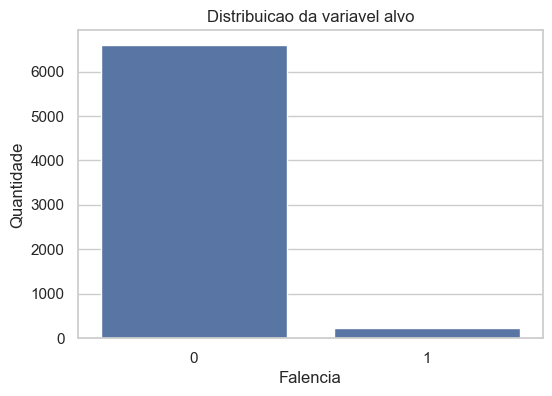

In [9]:
distribuicao_target = df[coluna_alvo].value_counts().rename_axis('classe').reset_index(name='quantidade')
display(distribuicao_target)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=coluna_alvo)
plt.title('Distribuicao da variavel alvo')
plt.xlabel('Falencia')
plt.ylabel('Quantidade')
plt.show()


In [10]:
colunas_preditoras = [coluna for coluna in df.columns if coluna != coluna_alvo]
colunas_numericas = df[colunas_preditoras].select_dtypes(include=['number']).columns.tolist()


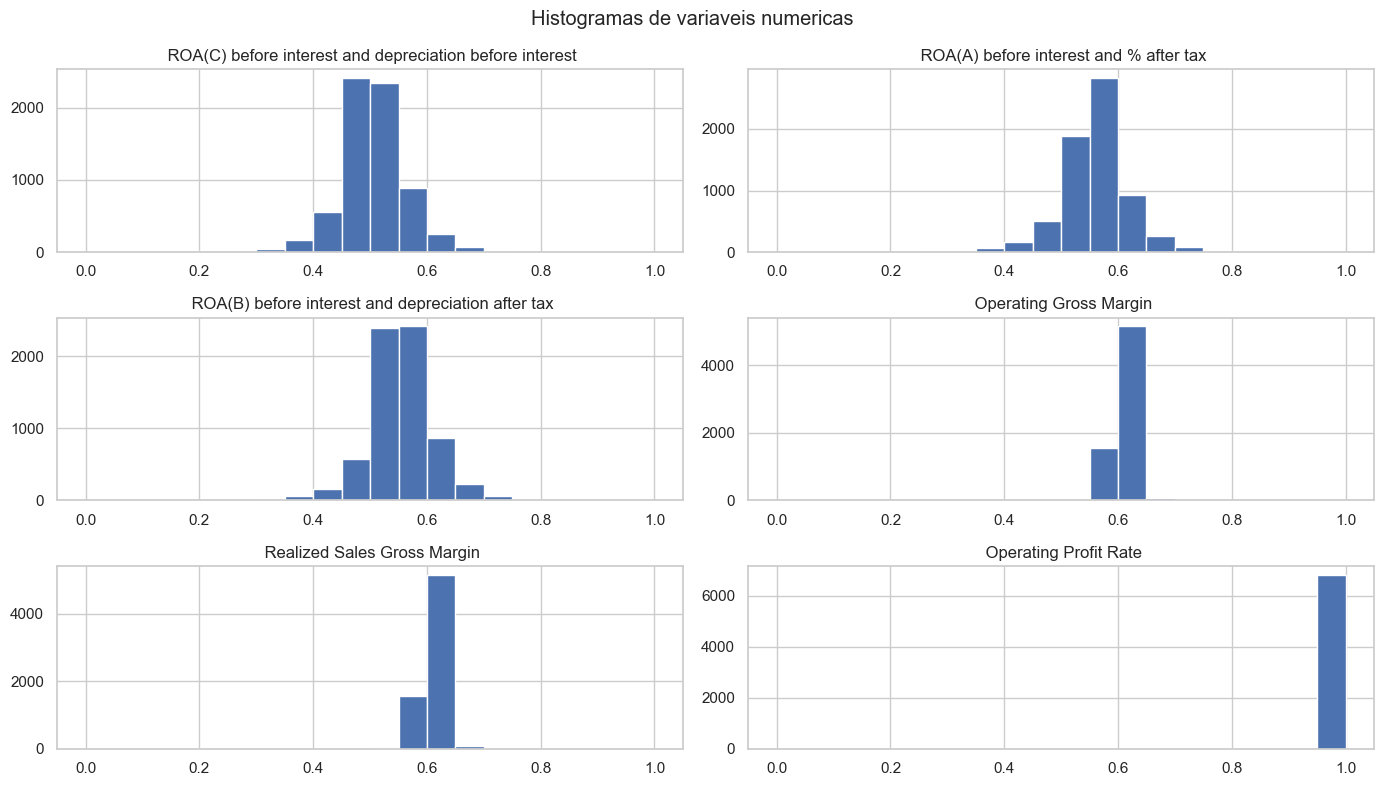

In [11]:
colunas_histograma = colunas_numericas[:6]
df[colunas_histograma].hist(figsize=(14, 8), bins=20)
plt.suptitle('Histogramas de variaveis numericas')
plt.tight_layout()
plt.show()


In [12]:
def gerar_boxplot(coluna_inicial=0, coluna_final=20, y_inicial_original=None, y_final_original=None, y_inicial_padronizado=None, y_final_padronizado=None):
    colunas_boxplot = colunas_numericas[coluna_inicial:coluna_final]
    dados_boxplot = df[colunas_boxplot].copy()

    scaler = StandardScaler()
    dados_boxplot_padronizado = pd.DataFrame(
        scaler.fit_transform(dados_boxplot),
        columns=colunas_boxplot,
        index=dados_boxplot.index
    )

    figura, eixos = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    dados_boxplot.boxplot(ax=eixos[0])
    eixos[0].set_title('Boxplot de variaveis numericas - escala original')
    eixos[0].set_ylabel('Escala da variavel')
    if y_inicial_original is not None and y_final_original is not None:
        eixos[0].set_ylim(y_inicial_original, y_final_original)

    dados_boxplot_padronizado.boxplot(ax=eixos[1])
    eixos[1].set_title('Boxplot de variaveis numericas - escala padronizada')
    eixos[1].set_ylabel('Escala padronizada')
    if y_inicial_padronizado is not None and y_final_padronizado is not None:
        eixos[1].set_ylim(y_inicial_padronizado, y_final_padronizado)
    eixos[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [13]:
def gerar_tabela_outliers(coluna_inicial=0, coluna_final=20):
    colunas_outliers = colunas_numericas[coluna_inicial:coluna_final]
    registros_outliers = []

    for coluna in colunas_outliers:
        q1 = df[coluna].quantile(0.25)
        q3 = df[coluna].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        mascara_outliers = (df[coluna] < limite_inferior) | (df[coluna] > limite_superior)
        quantidade_outliers = mascara_outliers.sum()
        percentual_outliers = (quantidade_outliers / len(df)) * 100

        registros_outliers.append({
            'coluna': coluna,
            'quantidade_outliers': quantidade_outliers,
            'percentual_outliers': percentual_outliers
        })

    return pd.DataFrame(registros_outliers).sort_values(by='percentual_outliers', ascending=False)


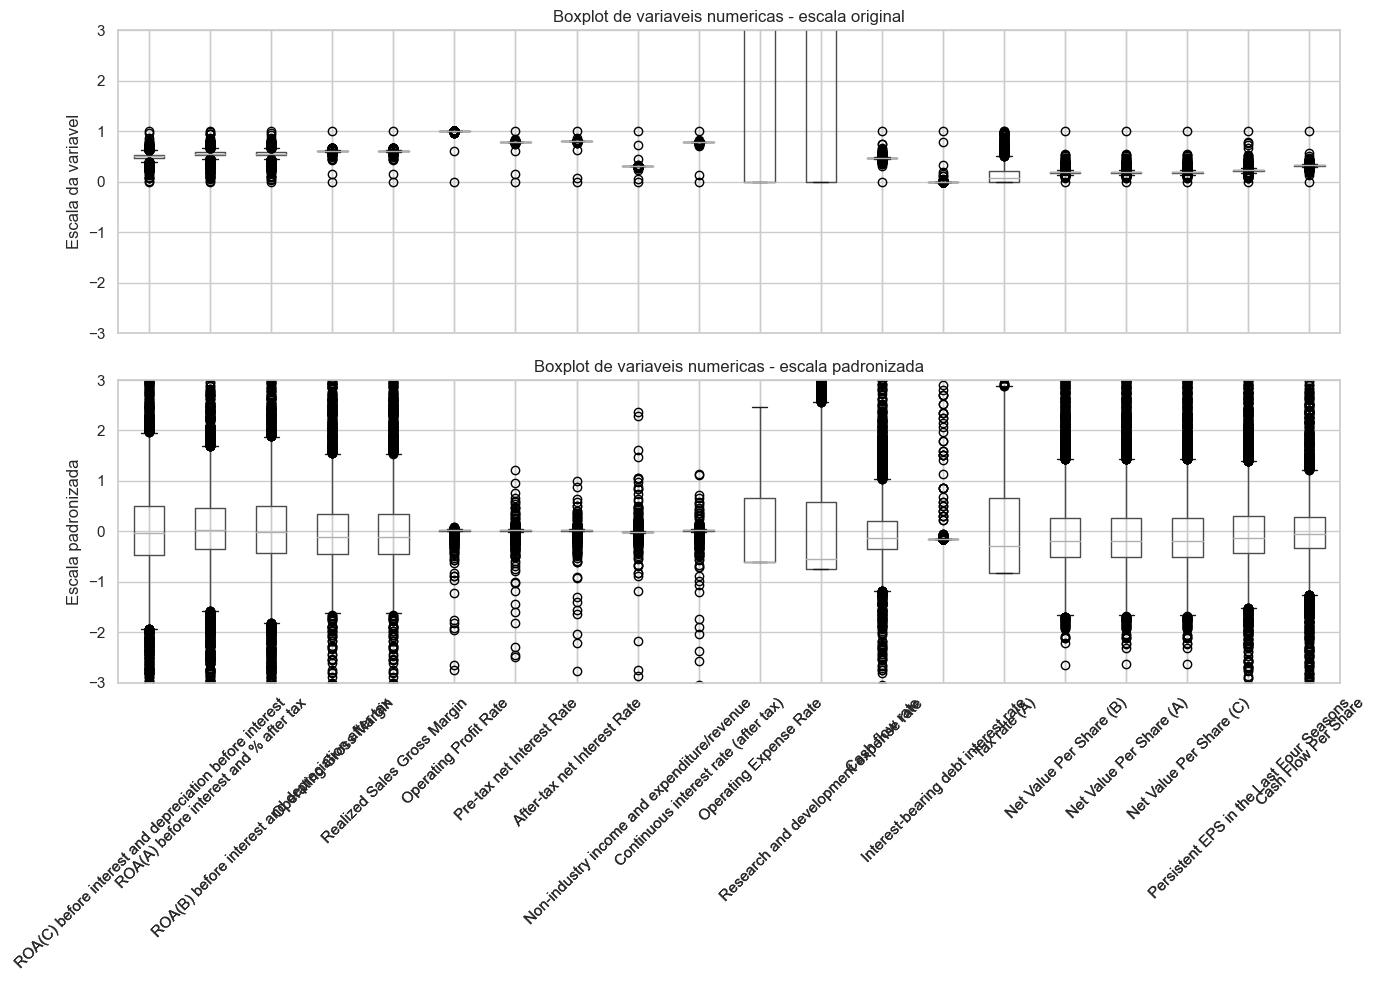

,coluna,quantidade_outliers,percentual_outliers
8,Non-industry income and expenditure/revenue,1094,16.0434
7,After-tax net Interest Rate,867,12.7145
9,Continuous interest rate (after tax),806,11.8199
6,Pre-tax net Interest Rate,773,11.3360
5,Operating Profit Rate,716,10.5001
12,Cash flow rate,576,8.4470
1,ROA(A) before interest and % after tax,561,8.2270
19,Cash Flow Per Share,532,7.8017
18,Persistent EPS in the Last Four Seasons,508,7.4498
17,Net Value Per Share (C),465,6.8192


In [14]:
coluna_inicial = 0
coluna_final = 20

y_inicial_original = -3
y_final_original = 3
y_inicial_padronizado = -3
y_final_padronizado = 3

gerar_boxplot(
    coluna_inicial=coluna_inicial,
    coluna_final=coluna_final,
    y_inicial_original=y_inicial_original,
    y_final_original=y_final_original,
    y_inicial_padronizado=y_inicial_padronizado,
    y_final_padronizado=y_final_padronizado
)

display(gerar_tabela_outliers(coluna_inicial=coluna_inicial, coluna_final=coluna_final))


Nesta etapa, foi realizada a analise exploratoria inicial, com verificacao de nulos, distribuicao da variavel alvo, histogramas, boxplots e outliers. A motivacao foi identificar caracteristicas importantes da base e possiveis problemas que poderiam influenciar a modelagem.


## 4. Limpeza e preparacao inicial

Agora vamos fazer os ajustes simples e separar as variaveis preditoras da variavel alvo.


In [15]:
colunas_originais = df.columns.tolist()
df.columns = df.columns.str.strip()
colunas_ajustadas = [
    {'antes': antes, 'depois': depois}
    for antes, depois in zip(colunas_originais, df.columns)
    if antes != depois
]

display(pd.DataFrame(colunas_ajustadas))


,antes,depois
0,ROA(C) before interest and depreciation befor...,ROA(C) before interest and depreciation before...
1,ROA(A) before interest and % after tax,ROA(A) before interest and % after tax
2,ROA(B) before interest and depreciation after...,ROA(B) before interest and depreciation after tax
3,Operating Gross Margin,Operating Gross Margin
4,Realized Sales Gross Margin,Realized Sales Gross Margin
...,...,...
90,Liability to Equity,Liability to Equity
91,Degree of Financial Leverage (DFL),Degree of Financial Leverage (DFL)
92,Interest Coverage Ratio (Interest expense to ...,Interest Coverage Ratio (Interest expense to E...
93,Net Income Flag,Net Income Flag


In [16]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]

print(f'X: {X.shape}')
print(f'y: {y.shape}')


X: (6819, 95)
y: (6819,)


In [17]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=random_state
)

print(f'X_treino: {X_treino.shape}')
print(f'X_teste: {X_teste.shape}')
print(f'y_treino: {y_treino.shape}')
print(f'y_teste: {y_teste.shape}')


X_treino: (4773, 95)
X_teste: (2046, 95)
y_treino: (4773,)
y_teste: (2046,)


Nesta etapa, foram feitos ajustes simples na base e a separacao entre variaveis preditoras e variavel alvo, alem da divisao entre treino e teste. A motivacao foi preparar os dados de forma organizada e evitar vazamento de informacao entre treinamento e avaliacao.


## 5. Pre-processamento

Nesta etapa, vamos montar o transformador para nulos, escalonamento e codificacao, quando necessario.


In [18]:
colunas_numericas_modelagem = X_treino.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas_modelagem = X_treino.select_dtypes(exclude=['number']).columns.tolist()

transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('padronizador', StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(handle_unknown='ignore'))
])

pre_processador = ColumnTransformer(transformers=[
    ('numericas', transformador_numerico, colunas_numericas_modelagem),
    ('categoricas', transformador_categorico, colunas_categoricas_modelagem)
])


Nesta etapa, foi estruturado o pre-processamento com imputacao, codificacao e padronizacao, conforme a necessidade das variaveis. A motivacao foi garantir que os modelos recebessem os dados em formato adequado e comparavel para a etapa de aprendizado.


## 6. Rodada de modelos base sem balanceamento

Aqui vamos testar 5 modelos base sem balanceamento e comparar os resultados na mesma estrutura.


In [19]:
def criacao_modelo(nome_modelo, estimador, X_treino, X_teste, y_treino, y_teste, pre_processador, cv=5, usar_smote=False):
    if usar_smote:
        pipeline_modelo = ImbPipeline(steps=[
            ('pre_processamento', pre_processador),
            ('smote', SMOTE(random_state=random_state)),
            ('modelo', estimador)
        ])
    else:
        pipeline_modelo = Pipeline(steps=[
            ('pre_processamento', pre_processador),
            ('modelo', estimador)
        ])

    pipeline_modelo.fit(X_treino, y_treino)

    previsoes_treino = pipeline_modelo.predict(X_treino)
    previsoes_teste = pipeline_modelo.predict(X_teste)

    acuracia_treino = accuracy_score(y_treino, previsoes_treino)
    acuracia_teste = accuracy_score(y_teste, previsoes_teste)
    diferenca_acuracia_treino_teste = abs(acuracia_treino - acuracia_teste)
    scores_validacao = cross_val_score(pipeline_modelo, X_treino, y_treino, cv=cv, scoring='accuracy')
    scores_cross_validation = [round(score, 4) for score in scores_validacao]
    diferenca_cross_validation = scores_validacao.max() - scores_validacao.min()
    relatorio_classificacao = classification_report(
        y_teste,
        previsoes_teste,
        output_dict=True,
        zero_division=0
    )

    return {
        'nome_modelo': nome_modelo,
        'pipeline_modelo': pipeline_modelo,
        'acuracia_treino': acuracia_treino,
        'acuracia_teste': acuracia_teste,
        'diferenca_acuracia_treino_teste': diferenca_acuracia_treino_teste,
        'cross_validation_media': scores_validacao.mean(),
        'cross_validation_desvio_padrao': scores_validacao.std(),
        'scores_cross_validation': scores_cross_validation,
        'diferenca_cross_validation': diferenca_cross_validation,
        'classification_report_dict': relatorio_classificacao
    }


In [20]:
def gerar_tabela_classe_1(resultados_modelos):
    registros_classe_1 = []

    for resultado_modelo in resultados_modelos:
        metricas_classe_1 = resultado_modelo['classification_report_dict'].get('1', {})
        registros_classe_1.append({
            'nome_modelo': resultado_modelo['nome_modelo'],
            'precision_classe_1': metricas_classe_1.get('precision', 0),
            'recall_classe_1': metricas_classe_1.get('recall', 0),
            'f1_classe_1': metricas_classe_1.get('f1-score', 0),
            'support_classe_1': metricas_classe_1.get('support', 0)
        })

    return pd.DataFrame(registros_classe_1).sort_values(by='f1_classe_1', ascending=False).reset_index(drop=True)


def gerar_tabela_relatorio_classificacao(relatorio_classificacao):
    return pd.DataFrame(relatorio_classificacao).T


def gerar_tabela_classe_1_modelo(nome_modelo, relatorio_classificacao):
    metricas_classe_1 = relatorio_classificacao.get('1', {})
    return pd.DataFrame([
        {
            'nome_modelo': nome_modelo,
            'precision_classe_1': metricas_classe_1.get('precision', 0),
            'recall_classe_1': metricas_classe_1.get('recall', 0),
            'f1_classe_1': metricas_classe_1.get('f1-score', 0),
            'support_classe_1': metricas_classe_1.get('support', 0)
        }
    ])


def criar_estimador(nome_modelo, usar_balanceamento=False):
    if nome_modelo == 'Regressao Logistica':
        return LogisticRegression(
            max_iter=2000,
            random_state=random_state,
            class_weight='balanced' if usar_balanceamento else None
        )
    if nome_modelo == 'KNN':
        return KNeighborsClassifier()
    if nome_modelo == 'Arvore de Decisao':
        return DecisionTreeClassifier(
            random_state=random_state,
            class_weight='balanced' if usar_balanceamento else None
        )
    if nome_modelo == 'Random Forest':
        return RandomForestClassifier(
            random_state=random_state,
            class_weight='balanced' if usar_balanceamento else None
        )
    return SVC(
        random_state=random_state,
        class_weight='balanced' if usar_balanceamento else None
    )


def criar_modelos_base(usar_balanceamento=False):
    nomes_modelos = [
        'Regressao Logistica',
        'KNN',
        'Arvore de Decisao',
        'Random Forest',
        'SVM'
    ]
    return {
        nome_modelo: criar_estimador(nome_modelo, usar_balanceamento=usar_balanceamento)
        for nome_modelo in nomes_modelos
    }


def exibir_relatorios_modelos(resultados_modelos, titulo):
    print(titulo)

    for resultado_modelo in resultados_modelos:
        print(f"Modelo: {resultado_modelo['nome_modelo']}")
        print(
            f"Acuracia de treino: {resultado_modelo['acuracia_treino']:.4f} | "
            f"Acuracia de teste: {resultado_modelo['acuracia_teste']:.4f} | "
            f"Dif: {resultado_modelo['diferenca_acuracia_treino_teste']:.4f}"
        )
        print(
            f"CV: {resultado_modelo['scores_cross_validation']} | "
            f"Dif CV: {resultado_modelo['diferenca_cross_validation']:.4f}"
        )
        display(gerar_tabela_relatorio_classificacao(resultado_modelo['classification_report_dict']))
        print('-' * 90)


In [21]:
modelos_base = criar_modelos_base(usar_balanceamento=False)


In [22]:
resultados_modelos_base = []

for nome_modelo, estimador in modelos_base.items():
    resultado_modelo = criacao_modelo(
        nome_modelo=nome_modelo,
        estimador=estimador,
        X_treino=X_treino,
        X_teste=X_teste,
        y_treino=y_treino,
        y_teste=y_teste,
        pre_processador=pre_processador
    )
    resultados_modelos_base.append(resultado_modelo)


In [23]:
tabela_modelos_base = pd.DataFrame(resultados_modelos_base).drop(columns=['pipeline_modelo', 'classification_report_dict'])
tabela_modelos_base = tabela_modelos_base.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)


In [24]:
tabela_classe_1_modelos_base = gerar_tabela_classe_1(resultados_modelos_base)


In [25]:
exibir_relatorios_modelos(
    resultados_modelos_base,
    titulo='Relatorios detalhados - modelos base sem balanceamento'
)


Relatorios detalhados - modelos base sem balanceamento
Modelo: Regressao Logistica
Acuracia de treino: 0.9728 | Acuracia de teste: 0.9633 | Dif: 0.0094
CV: [0.9644, 0.9665, 0.9665, 0.9654, 0.9696] | Dif CV: 0.0052


,precision,recall,f1-score,support
0,0.9732,0.9894,0.9812,1980.0000
1,0.3636,0.1818,0.2424,66.0000
accuracy,0.9633,0.9633,0.9633,0.9633
macro avg,0.6684,0.5856,0.6118,2046.0000
weighted avg,0.9535,0.9633,0.9574,2046.0000


------------------------------------------------------------------------------------------
Modelo: KNN
Acuracia de treino: 0.9751 | Acuracia de teste: 0.9677 | Dif: 0.0073
CV: [0.9634, 0.9696, 0.9686, 0.9727, 0.9665] | Dif CV: 0.0094


,precision,recall,f1-score,support
0,0.9705,0.9970,0.9836,1980.0000
1,0.5000,0.0909,0.1538,66.0000
accuracy,0.9677,0.9677,0.9677,0.9677
macro avg,0.7353,0.5439,0.5687,2046.0000
weighted avg,0.9553,0.9677,0.9568,2046.0000


------------------------------------------------------------------------------------------
Modelo: Arvore de Decisao
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9516 | Dif: 0.0484
CV: [0.955, 0.9508, 0.9592, 0.9486, 0.9581] | Dif CV: 0.0105


...

------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9702 | Dif: 0.0298
CV: [0.9686, 0.9707, 0.9707, 0.9727, 0.9706] | Dif CV: 0.0042


,precision,recall,f1-score,support
0,0.9734,0.9965,0.9848,1980.0000
1,0.6316,0.1818,0.2824,66.0000
accuracy,0.9702,0.9702,0.9702,0.9702
macro avg,0.8025,0.5891,0.6336,2046.0000
weighted avg,0.9623,0.9702,0.9621,2046.0000


------------------------------------------------------------------------------------------
Modelo: SVM
Acuracia de treino: 0.9732 | Acuracia de teste: 0.9677 | Dif: 0.0054
CV: [0.9675, 0.9686, 0.9675, 0.9686, 0.9675] | Dif CV: 0.0011


,precision,recall,f1-score,support
0,0.9677,1.0000,0.9836,1980.0000
1,0.0000,0.0000,0.0000,66.0000
accuracy,0.9677,0.9677,0.9677,0.9677
macro avg,0.4839,0.5000,0.4918,2046.0000
weighted avg,0.9365,0.9677,0.9519,2046.0000


------------------------------------------------------------------------------------------


In [26]:
melhor_modelo_base = tabela_modelos_base.iloc[0]['nome_modelo']
print(f'Melhor modelo base sem PCA: {melhor_modelo_base}')


Melhor modelo base sem PCA: Random Forest


Nesta etapa, observou-se que a acuracia global alta nao garantiu bom desempenho na identificacao de empresas falidas. A analise mostrou dificuldade dos modelos em reconhecer esses casos, por isso o `recall` e o `f1-score` se mostraram mais relevantes do que a acuracia isolada. A diferenca entre treino e teste e a variacao da validacao cruzada tambem ajudaram a avaliar overfitting e estabilidade.


## 7. Rodada de modelos base com SMOTE

Nesta etapa, vamos repetir a rodada dos 5 modelos usando `SMOTE` apenas no treino para ampliar a representatividade da classe de empresas falidas.


In [27]:
modelos_base_smote = criar_modelos_base(usar_balanceamento=False)

resultados_modelos_base_smote = []

for nome_modelo, estimador in modelos_base_smote.items():
    resultado_modelo = criacao_modelo(
        nome_modelo=nome_modelo,
        estimador=estimador,
        X_treino=X_treino,
        X_teste=X_teste,
        y_treino=y_treino,
        y_teste=y_teste,
        pre_processador=pre_processador,
        usar_smote=True
    )
    resultados_modelos_base_smote.append(resultado_modelo)


In [28]:
tabela_modelos_base_smote = pd.DataFrame(resultados_modelos_base_smote).drop(columns=['pipeline_modelo', 'classification_report_dict'])
tabela_modelos_base_smote = tabela_modelos_base_smote.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)


In [29]:
tabela_classe_1_modelos_base_smote = gerar_tabela_classe_1(resultados_modelos_base_smote)


In [30]:
exibir_relatorios_modelos(
    resultados_modelos_base_smote,
    titulo='Relatorios detalhados - modelos base com SMOTE'
)


Relatorios detalhados - modelos base com SMOTE
Modelo: Regressao Logistica
Acuracia de treino: 0.8923 | Acuracia de teste: 0.8871 | Dif: 0.0052
CV: [0.8796, 0.8764, 0.8932, 0.8836, 0.9151] | Dif CV: 0.0387


,precision,recall,f1-score,support
0,0.9899,0.8924,0.9386,1980.0000
1,0.1839,0.7273,0.2936,66.0000
accuracy,0.8871,0.8871,0.8871,0.8871
macro avg,0.5869,0.8098,0.6161,2046.0000
weighted avg,0.9639,0.8871,0.9178,2046.0000


------------------------------------------------------------------------------------------
Modelo: KNN
Acuracia de treino: 0.9244 | Acuracia de teste: 0.8837 | Dif: 0.0407
CV: [0.888, 0.8859, 0.8775, 0.8941, 0.8899] | Dif CV: 0.0166


,precision,recall,f1-score,support
0,0.9860,0.8924,0.9369,1980.0000
1,0.1614,0.6212,0.2562,66.0000
accuracy,0.8837,0.8837,0.8837,0.8837
macro avg,0.5737,0.7568,0.5966,2046.0000
weighted avg,0.9594,0.8837,0.9149,2046.0000


------------------------------------------------------------------------------------------
Modelo: Arvore de Decisao
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9433 | Dif: 0.0567
CV: [0.9089, 0.9246, 0.9455, 0.9245, 0.9203] | Dif CV: 0.0366


...

------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9609 | Dif: 0.0391
CV: [0.9435, 0.9529, 0.9592, 0.9623, 0.9602] | Dif CV: 0.0188


,precision,recall,f1-score,support
0,0.9847,0.9747,0.9797,1980.0000
1,0.4186,0.5455,0.4737,66.0000
accuracy,0.9609,0.9609,0.9609,0.9609
macro avg,0.7016,0.7601,0.7267,2046.0000
weighted avg,0.9664,0.9609,0.9634,2046.0000


------------------------------------------------------------------------------------------
Modelo: SVM
Acuracia de treino: 0.9260 | Acuracia de teste: 0.9032 | Dif: 0.0228
CV: [0.8963, 0.8974, 0.912, 0.9036, 0.9109] | Dif CV: 0.0157


,precision,recall,f1-score,support
0,0.9842,0.9146,0.9482,1980.0000
1,0.1796,0.5606,0.2721,66.0000
accuracy,0.9032,0.9032,0.9032,0.9032
macro avg,0.5819,0.7376,0.6101,2046.0000
weighted avg,0.9583,0.9032,0.9264,2046.0000


------------------------------------------------------------------------------------------


In [31]:
melhor_modelo_base_smote = tabela_modelos_base_smote.iloc[0]['nome_modelo']
print(f'Melhor modelo base com SMOTE: {melhor_modelo_base_smote}')


Melhor modelo base com SMOTE: Random Forest


In [32]:
melhor_resultado_sem_balanceamento = next(
    resultado_modelo
    for resultado_modelo in resultados_modelos_base
    if resultado_modelo['nome_modelo'] == melhor_modelo_base
)

melhor_resultado_smote = next(
    resultado_modelo
    for resultado_modelo in resultados_modelos_base_smote
    if resultado_modelo['nome_modelo'] == melhor_modelo_base_smote
)

exibir_relatorios_modelos(
    [melhor_resultado_sem_balanceamento, melhor_resultado_smote],
    titulo='Relatorios detalhados - melhores modelos das estrategias sem balanceamento e com SMOTE'
)


Relatorios detalhados - melhores modelos das estrategias sem balanceamento e com SMOTE
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9702 | Dif: 0.0298
CV: [0.9686, 0.9707, 0.9707, 0.9727, 0.9706] | Dif CV: 0.0042


,precision,recall,f1-score,support
0,0.9734,0.9965,0.9848,1980.0000
1,0.6316,0.1818,0.2824,66.0000
accuracy,0.9702,0.9702,0.9702,0.9702
macro avg,0.8025,0.5891,0.6336,2046.0000
weighted avg,0.9623,0.9702,0.9621,2046.0000


------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9609 | Dif: 0.0391
CV: [0.9435, 0.9529, 0.9592, 0.9623, 0.9602] | Dif CV: 0.0188


,precision,recall,f1-score,support
0,0.9847,0.9747,0.9797,1980.0000
1,0.4186,0.5455,0.4737,66.0000
accuracy,0.9609,0.9609,0.9609,0.9609
macro avg,0.7016,0.7601,0.7267,2046.0000
weighted avg,0.9664,0.9609,0.9634,2046.0000


------------------------------------------------------------------------------------------


In [33]:
usar_smote = True

if usar_smote:
    descricao_trilha_smote = 'Com SMOTE'
    melhor_modelo_base_ativo = melhor_modelo_base_smote
else:
    descricao_trilha_smote = 'Sem SMOTE'
    melhor_modelo_base_ativo = melhor_modelo_base

print(f'Trilha escolhida para as proximas etapas: {descricao_trilha_smote}')
print(f'Melhor modelo base da estrategia escolhida: {melhor_modelo_base_ativo}')


Trilha escolhida para as proximas etapas: Com SMOTE
Melhor modelo base da estrategia escolhida: Random Forest


Com `SMOTE`, observou-se melhora na identificacao de empresas falidas, mesmo com pequena variacao na acuracia global. Esse resultado indicou que a trilha com `SMOTE` ficou mais adequada ao problema, pois passou a reconhecer melhor os casos de falencia sem perda excessiva de estabilidade.


## 8. Otimizacao do melhor modelo da estrategia atual

Agora vamos usar Grid Search no melhor modelo da estrategia escolhida na etapa anterior, permitindo tambem testar `class_weight='balanced'` quando isso fizer sentido para o algoritmo.


In [34]:
if melhor_modelo_base_ativo == 'Regressao Logistica':
    melhor_estimador_sem_pca = LogisticRegression(max_iter=2000, random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__solver': ['lbfgs', 'liblinear'],
        'modelo__class_weight': [None, 'balanced']
    }
elif melhor_modelo_base_ativo == 'KNN':
    melhor_estimador_sem_pca = KNeighborsClassifier()
    grade_parametros_sem_pca = {
        'modelo__n_neighbors': [3, 5, 7, 9],
        'modelo__weights': ['uniform', 'distance']
    }
elif melhor_modelo_base_ativo == 'Arvore de Decisao':
    melhor_estimador_sem_pca = DecisionTreeClassifier(random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__max_depth': [3, 5, 10, None],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__class_weight': [None, 'balanced']
    }
elif melhor_modelo_base_ativo == 'Random Forest':
    melhor_estimador_sem_pca = RandomForestClassifier(random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [None, 5, 10],
        'modelo__min_samples_split': [2, 5],
        'modelo__class_weight': [None, 'balanced']
    }
else:
    melhor_estimador_sem_pca = SVC(random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__kernel': ['linear', 'rbf'],
        'modelo__class_weight': [None, 'balanced']
    }


In [35]:
if usar_smote:
    pipeline_otimizacao_sem_pca = ImbPipeline(steps=[
        ('pre_processamento', pre_processador),
        ('smote', SMOTE(random_state=random_state)),
        ('modelo', melhor_estimador_sem_pca)
    ])
else:
    pipeline_otimizacao_sem_pca = Pipeline(steps=[
        ('pre_processamento', pre_processador),
        ('modelo', melhor_estimador_sem_pca)
    ])

grid_search_sem_pca = GridSearchCV(
    estimator=pipeline_otimizacao_sem_pca,
    param_grid=grade_parametros_sem_pca,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_sem_pca.fit(X_treino, y_treino)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre_processamento',
                                        ColumnTransformer(transformers=[('numericas',
                                                                         Pipeline(steps=[('imputador',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('padronizador',
                                                                                          StandardScaler())]),
                                                                         ['ROA(C) '
                                                                          'before '
                                                                          'interest '
                                                                          'and '
                                                                          'depreciation '
                                                                          'before '
                                                                          'interest',
                                                                          'ROA(A) '
                                                                          'before '
                                                                          'interest '
                                                                          'and '
                                                                          '% '
                                                                          'after '
                                                                          'tax',
                                                                          'ROA(B) '
                                                                          'before '
                                                                          'interest '
                                                                          'an...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('codificador',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         [])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': [None, 'balanced'],
                         'modelo__max_depth': [None, 5, 10],
                         'modelo__min_samples_split': [2, 5],
                         'modelo__n_estimators': [100, 200]},
             scoring='accuracy')

In [36]:
melhor_pipeline_sem_pca = grid_search_sem_pca.best_estimator_
previsoes_treino_sem_pca = melhor_pipeline_sem_pca.predict(X_treino)
previsoes_sem_pca = melhor_pipeline_sem_pca.predict(X_teste)

acuracia_treino_sem_pca = accuracy_score(y_treino, previsoes_treino_sem_pca)
acuracia_teste_sem_pca = accuracy_score(y_teste, previsoes_sem_pca)
diferenca_acuracia_sem_pca = abs(acuracia_treino_sem_pca - acuracia_teste_sem_pca)
scores_validacao_sem_pca = cross_val_score(
    melhor_pipeline_sem_pca,
    X_treino,
    y_treino,
    cv=5,
    scoring='accuracy'
)
scores_cross_validation_sem_pca = [round(score, 4) for score in scores_validacao_sem_pca]
diferenca_cross_validation_sem_pca = scores_validacao_sem_pca.max() - scores_validacao_sem_pca.min()

relatorio_sem_pca = classification_report(
    y_teste,
    previsoes_sem_pca,
    output_dict=True,
    zero_division=0
)

print('-' * 90)
print(f'Modelo: {melhor_modelo_base_ativo}')
print(
    f'Acuracia de treino: {acuracia_treino_sem_pca:.4f} | '
    f'Acuracia de teste: {acuracia_teste_sem_pca:.4f} | '
    f'Dif: {diferenca_acuracia_sem_pca:.4f}'
)
print(
    f'CV: {scores_cross_validation_sem_pca} | '
    f'Dif CV: {diferenca_cross_validation_sem_pca:.4f}'
)
print()
display(gerar_tabela_relatorio_classificacao(relatorio_sem_pca))
print('Melhores parametros sem PCA:')
print(grid_search_sem_pca.best_params_)


------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9609 | Dif: 0.0391
CV: [0.9435, 0.9529, 0.9592, 0.9623, 0.9602] | Dif CV: 0.0188



,precision,recall,f1-score,support
0,0.9847,0.9747,0.9797,1980.0000
1,0.4186,0.5455,0.4737,66.0000
accuracy,0.9609,0.9609,0.9609,0.9609
macro avg,0.7016,0.7601,0.7267,2046.0000
weighted avg,0.9664,0.9609,0.9634,2046.0000


Melhores parametros sem PCA:
{'modelo__class_weight': None, 'modelo__max_depth': None, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}


Na otimizacao, observou-se se o ajuste de hiperparametros melhorou o modelo sem comprometer a generalizacao. A analise confirmou a identificacao de empresas falidas como ponto principal e permitiu verificar se o modelo continuou estavel apos a busca pelos melhores parametros.


## 9. PCA e escolha da dimensionalidade

Nesta etapa, vamos estudar a variancia explicada acumulada para escolher a quantidade de componentes.


In [37]:
dados_treino_pre_processados = pre_processador.fit_transform(X_treino)

if hasattr(dados_treino_pre_processados, 'toarray'):
    dados_treino_pre_processados = dados_treino_pre_processados.toarray()


In [38]:
pca_completo = PCA()
pca_completo.fit(dados_treino_pre_processados)

variancia_explicada_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
tabela_pca = pd.DataFrame({
    'componente': np.arange(1, len(variancia_explicada_acumulada) + 1),
    'variancia_explicada_acumulada': variancia_explicada_acumulada
})

display(tabela_pca.head(15))


,componente,variancia_explicada_acumulada
0,1,0.1366
1,2,0.2110
2,3,0.2776
3,4,0.3275
4,5,0.3707
5,6,0.4071
6,7,0.4421
7,8,0.4725
8,9,0.4982
9,10,0.5210


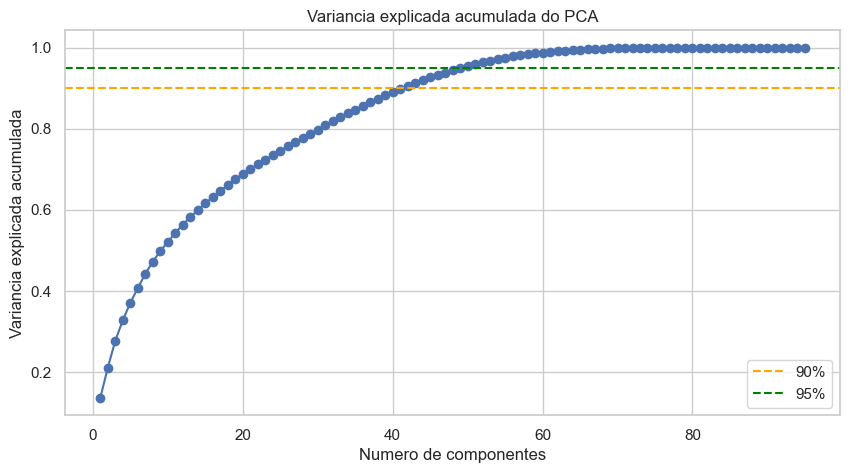

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(tabela_pca['componente'], tabela_pca['variancia_explicada_acumulada'], marker='o')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90%')
plt.axhline(y=0.95, color='green', linestyle='--', label='95%')
plt.title('Variancia explicada acumulada do PCA')
plt.xlabel('Numero de componentes')
plt.ylabel('Variancia explicada acumulada')
plt.legend()
plt.show()


In [40]:
quantidade_componentes_pca = int((variancia_explicada_acumulada >= 0.95).argmax() + 1)
print(f'Quantidade inicial de componentes escolhida para o PCA: {quantidade_componentes_pca}')


Quantidade inicial de componentes escolhida para o PCA: 50


Na etapa de PCA, observou-se o quanto da informacao original foi mantido apos a reducao de dimensionalidade. O numero de componentes foi interpretado a partir da variancia explicada acumulada e da leitura visual da curva, para avaliar se a simplificacao da base era justificavel.


## 10. Rodada de modelos base com PCA

Agora vamos repetir a rodada de 5 modelos usando a base transformada por PCA e mantendo a estrategia escolhida.


In [41]:
pre_processador_com_pca = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('pca', PCA(n_components=quantidade_componentes_pca))
])


In [42]:
resultados_modelos_base_pca = []

if usar_smote:
    modelos_base_pca_ativos = modelos_base_smote
else:
    modelos_base_pca_ativos = modelos_base

for nome_modelo, estimador in modelos_base_pca_ativos.items():
    if usar_smote:
        pipeline_modelo_pca = ImbPipeline(steps=[
            ('pre_processamento', pre_processador),
            ('smote', SMOTE(random_state=random_state)),
            ('pca', PCA(n_components=quantidade_componentes_pca)),
            ('modelo', estimador)
        ])
    else:
        pipeline_modelo_pca = Pipeline(steps=[
            ('pre_processamento', pre_processador),
            ('pca', PCA(n_components=quantidade_componentes_pca)),
            ('modelo', estimador)
        ])

    pipeline_modelo_pca.fit(X_treino, y_treino)

    previsoes_treino_pca = pipeline_modelo_pca.predict(X_treino)
    previsoes_teste_pca = pipeline_modelo_pca.predict(X_teste)

    acuracia_treino_pca = accuracy_score(y_treino, previsoes_treino_pca)
    acuracia_teste_pca = accuracy_score(y_teste, previsoes_teste_pca)
    diferenca_acuracia_treino_teste_pca = abs(acuracia_treino_pca - acuracia_teste_pca)
    scores_validacao_pca = cross_val_score(
        pipeline_modelo_pca,
        X_treino,
        y_treino,
        cv=5,
        scoring='accuracy'
    )
    scores_cross_validation_pca = [round(score, 4) for score in scores_validacao_pca]
    diferenca_cross_validation_pca = scores_validacao_pca.max() - scores_validacao_pca.min()
    relatorio_classificacao_pca = classification_report(
        y_teste,
        previsoes_teste_pca,
        output_dict=True,
        zero_division=0
    )

    resultados_modelos_base_pca.append({
        'nome_modelo': nome_modelo,
        'pipeline_modelo': pipeline_modelo_pca,
        'acuracia_treino': acuracia_treino_pca,
        'acuracia_teste': acuracia_teste_pca,
        'diferenca_acuracia_treino_teste': diferenca_acuracia_treino_teste_pca,
        'cross_validation_media': scores_validacao_pca.mean(),
        'cross_validation_desvio_padrao': scores_validacao_pca.std(),
        'scores_cross_validation': scores_cross_validation_pca,
        'diferenca_cross_validation': diferenca_cross_validation_pca,
        'classification_report_dict': relatorio_classificacao_pca
    })


In [43]:
tabela_modelos_base_pca = pd.DataFrame(resultados_modelos_base_pca).drop(columns=['pipeline_modelo', 'classification_report_dict'])
tabela_modelos_base_pca = tabela_modelos_base_pca.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)


In [44]:
tabela_classe_1_modelos_base_pca = gerar_tabela_classe_1(resultados_modelos_base_pca)


In [45]:
exibir_relatorios_modelos(
    resultados_modelos_base_pca,
    titulo='Relatorios detalhados - modelos base com PCA'
)


Relatorios detalhados - modelos base com PCA
Modelo: Regressao Logistica
Acuracia de treino: 0.8758 | Acuracia de teste: 0.8675 | Dif: 0.0082
CV: [0.8733, 0.8607, 0.8806, 0.8658, 0.8836] | Dif CV: 0.0229


,precision,recall,f1-score,support
0,0.9902,0.8717,0.9272,1980.0000
1,0.1617,0.7424,0.2656,66.0000
accuracy,0.8675,0.8675,0.8675,0.8675
macro avg,0.5760,0.8071,0.5964,2046.0000
weighted avg,0.9635,0.8675,0.9059,2046.0000


------------------------------------------------------------------------------------------
Modelo: KNN
Acuracia de treino: 0.9237 | Acuracia de teste: 0.8807 | Dif: 0.0430
CV: [0.8942, 0.8796, 0.8806, 0.892, 0.8952] | Dif CV: 0.0156


,precision,recall,f1-score,support
0,0.9860,0.8894,0.9352,1980.0000
1,0.1577,0.6212,0.2515,66.0000
accuracy,0.8807,0.8807,0.8807,0.8807
macro avg,0.5718,0.7553,0.5934,2046.0000
weighted avg,0.9593,0.8807,0.9132,2046.0000


------------------------------------------------------------------------------------------
Modelo: Arvore de Decisao
Acuracia de treino: 0.9994 | Acuracia de teste: 0.9355 | Dif: 0.0639
CV: [0.9236, 0.9288, 0.9351, 0.913, 0.9235] | Dif CV: 0.0221


...

------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9560 | Dif: 0.0440
CV: [0.9571, 0.9571, 0.9602, 0.9539, 0.9654] | Dif CV: 0.0115


,precision,recall,f1-score,support
0,0.9773,0.9773,0.9773,1980.0000
1,0.3182,0.3182,0.3182,66.0000
accuracy,0.9560,0.9560,0.9560,0.9560
macro avg,0.6477,0.6477,0.6477,2046.0000
weighted avg,0.9560,0.9560,0.9560,2046.0000


------------------------------------------------------------------------------------------
Modelo: SVM
Acuracia de treino: 0.9223 | Acuracia de teste: 0.9027 | Dif: 0.0195
CV: [0.8901, 0.8984, 0.9047, 0.9109, 0.914] | Dif CV: 0.0240


,precision,recall,f1-score,support
0,0.9848,0.9136,0.9479,1980.0000
1,0.1818,0.5758,0.2764,66.0000
accuracy,0.9027,0.9027,0.9027,0.9027
macro avg,0.5833,0.7447,0.6121,2046.0000
weighted avg,0.9589,0.9027,0.9262,2046.0000


------------------------------------------------------------------------------------------


In [46]:
melhor_modelo_base_pca = tabela_modelos_base_pca.iloc[0]['nome_modelo']
print(f'Melhor modelo base com PCA: {melhor_modelo_base_pca}')
print(f'Parametro de smote utilizado: {"Sim" if usar_smote else "Nao"}')


Melhor modelo base com PCA: Random Forest
Parametro de smote utilizado: Sim


Com PCA, observou-se se a reducao de dimensionalidade ajudou ou prejudicou o desempenho dos modelos. A comparacao mostrou se a nova representacao dos dados manteve a capacidade de identificacao de empresas falidas com qualidade semelhante ou superior a trilha sem PCA.


## 11. Otimizacao do melhor modelo com PCA

Nesta etapa, vamos otimizar o melhor modelo encontrado na trilha com PCA, mantendo a estrategia escolhida.


In [47]:
valores_componentes_pca = sorted(set([
    max(2, quantidade_componentes_pca - 2),
    quantidade_componentes_pca,
    min(len(colunas_numericas_modelagem), quantidade_componentes_pca + 2)
]))

if melhor_modelo_base_pca == 'Regressao Logistica':
    melhor_estimador_com_pca = LogisticRegression(max_iter=2000, random_state=random_state)
    grade_parametros_com_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__solver': ['lbfgs', 'liblinear'],
        'modelo__class_weight': [None, 'balanced'],
        'pca__n_components': valores_componentes_pca
    }
elif melhor_modelo_base_pca == 'KNN':
    melhor_estimador_com_pca = KNeighborsClassifier()
    grade_parametros_com_pca = {
        'modelo__n_neighbors': [3, 5, 7, 9],
        'modelo__weights': ['uniform', 'distance'],
        'pca__n_components': valores_componentes_pca
    }
elif melhor_modelo_base_pca == 'Arvore de Decisao':
    melhor_estimador_com_pca = DecisionTreeClassifier(random_state=random_state)
    grade_parametros_com_pca = {
        'modelo__max_depth': [3, 5, 10, None],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__class_weight': [None, 'balanced'],
        'pca__n_components': valores_componentes_pca
    }
elif melhor_modelo_base_pca == 'Random Forest':
    melhor_estimador_com_pca = RandomForestClassifier(random_state=random_state)
    grade_parametros_com_pca = {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [None, 5, 10],
        'modelo__min_samples_split': [2, 5],
        'modelo__class_weight': [None, 'balanced'],
        'pca__n_components': valores_componentes_pca
    }
else:
    melhor_estimador_com_pca = SVC(random_state=random_state)
    grade_parametros_com_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__kernel': ['linear', 'rbf'],
        'modelo__class_weight': [None, 'balanced'],
        'pca__n_components': valores_componentes_pca
    }


In [48]:
if usar_smote:
    pipeline_otimizacao_com_pca = ImbPipeline(steps=[
        ('pre_processamento', pre_processador),
        ('smote', SMOTE(random_state=random_state)),
        ('pca', PCA(n_components=quantidade_componentes_pca)),
        ('modelo', melhor_estimador_com_pca)
    ])
else:
    pipeline_otimizacao_com_pca = Pipeline(steps=[
        ('pre_processamento', pre_processador),
        ('pca', PCA(n_components=quantidade_componentes_pca)),
        ('modelo', melhor_estimador_com_pca)
    ])

grid_search_com_pca = GridSearchCV(
    estimator=pipeline_otimizacao_com_pca,
    param_grid=grade_parametros_com_pca,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_com_pca.fit(X_treino, y_treino)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre_processamento',
                                        ColumnTransformer(transformers=[('numericas',
                                                                         Pipeline(steps=[('imputador',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('padronizador',
                                                                                          StandardScaler())]),
                                                                         ['ROA(C) '
                                                                          'before '
                                                                          'interest '
                                                                          'and '
                                                                          'depreciation '
                                                                          'before '
                                                                          'interest',
                                                                          'ROA(A) '
                                                                          'before '
                                                                          'interest '
                                                                          'and '
                                                                          '% '
                                                                          'after '
                                                                          'tax',
                                                                          'ROA(B) '
                                                                          'before '
                                                                          'interest '
                                                                          'an...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         [])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('pca', PCA(n_components=50)),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': [None, 'balanced'],
                         'modelo__max_depth': [None, 5, 10],
                         'modelo__min_samples_split': [2, 5],
                         'modelo__n_estimators': [100, 200],
                         'pca__n_components': [48, 50, 52]},
             scoring='accuracy')

In [49]:
melhor_pipeline_com_pca = grid_search_com_pca.best_estimator_
previsoes_treino_com_pca = melhor_pipeline_com_pca.predict(X_treino)
previsoes_com_pca = melhor_pipeline_com_pca.predict(X_teste)

acuracia_treino_com_pca = accuracy_score(y_treino, previsoes_treino_com_pca)
acuracia_teste_com_pca = accuracy_score(y_teste, previsoes_com_pca)
diferenca_acuracia_com_pca = abs(acuracia_treino_com_pca - acuracia_teste_com_pca)
scores_validacao_com_pca = cross_val_score(
    melhor_pipeline_com_pca,
    X_treino,
    y_treino,
    cv=5,
    scoring='accuracy'
)
scores_cross_validation_com_pca = [round(score, 4) for score in scores_validacao_com_pca]
diferenca_cross_validation_com_pca = scores_validacao_com_pca.max() - scores_validacao_com_pca.min()

relatorio_com_pca = classification_report(
    y_teste,
    previsoes_com_pca,
    output_dict=True,
    zero_division=0
)

print('-' * 90)
print(f'Modelo: {melhor_modelo_base_pca}')
print(
    f'Acuracia de treino: {acuracia_treino_com_pca:.4f} | '
    f'Acuracia de teste: {acuracia_teste_com_pca:.4f} | '
    f'Dif: {diferenca_acuracia_com_pca:.4f}'
)
print(
    f'CV: {scores_cross_validation_com_pca} | '
    f'Dif CV: {diferenca_cross_validation_com_pca:.4f}'
)
print()
display(gerar_tabela_relatorio_classificacao(relatorio_com_pca))
print('Melhores parametros com PCA:')
print(grid_search_com_pca.best_params_)


------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9550 | Dif: 0.0450
CV: [0.9518, 0.955, 0.9613, 0.957, 0.9654] | Dif CV: 0.0136



,precision,recall,f1-score,support
0,0.9768,0.9768,0.9768,1980.0000
1,0.3030,0.3030,0.3030,66.0000
accuracy,0.9550,0.9550,0.9550,0.9550
macro avg,0.6399,0.6399,0.6399,2046.0000
weighted avg,0.9550,0.9550,0.9550,2046.0000


Melhores parametros com PCA:
{'modelo__class_weight': None, 'modelo__max_depth': None, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100, 'pca__n_components': 48}


Na otimizacao com PCA, observou-se o desempenho final dessa trilha apos o ajuste dos parametros. Quando os resultados para identificacao de empresas falidas permaneceram inferiores aos da abordagem sem PCA, isso indicou que a reducao de dimensionalidade nao trouxe ganho pratico suficiente para a solucao final.


## 12. Comparacao final e conclusao

Por fim, vamos reunir os resultados das duas trilhas para apoiar a conclusao do estudo.


In [50]:
comparacao_final = pd.DataFrame([
    {
        'abordagem': 'Sem PCA',
        'trilha_smote': descricao_trilha_smote,
        'modelo': melhor_modelo_base_ativo,
        'acuracia_treino': acuracia_treino_sem_pca,
        'acuracia_teste': acuracia_teste_sem_pca,
        'dif': diferenca_acuracia_sem_pca,
        'scores_cv': scores_cross_validation_sem_pca,
        'dif_cv': diferenca_cross_validation_sem_pca,
        'melhor_score_validacao': grid_search_sem_pca.best_score_
    },
    {
        'abordagem': 'Com PCA',
        'trilha_smote': descricao_trilha_smote,
        'modelo': melhor_modelo_base_pca,
        'acuracia_treino': acuracia_treino_com_pca,
        'acuracia_teste': acuracia_teste_com_pca,
        'dif': diferenca_acuracia_com_pca,
        'scores_cv': scores_cross_validation_com_pca,
        'dif_cv': diferenca_cross_validation_com_pca,
        'melhor_score_validacao': grid_search_com_pca.best_score_
    }
])

display(comparacao_final)


,abordagem,trilha_smote,modelo,acuracia_treino,acuracia_teste,dif,scores_cv,dif_cv,melhor_score_validacao
0,Sem PCA,Com SMOTE,Random Forest,1.0000,0.9609,0.0391,"[0.9435, 0.9529, 0.9592, 0.9623, 0.9602]",0.0188,0.9556
1,Com PCA,Com SMOTE,Random Forest,1.0000,0.9550,0.0450,"[0.9518, 0.955, 0.9613, 0.957, 0.9654]",0.0136,0.9596


In [51]:
print('-' * 90)
print(f"Modelo: {melhor_modelo_base_ativo} | Abordagem: Sem PCA")
print(
    f"Acuracia de treino: {acuracia_treino_sem_pca:.4f} | "
    f"Acuracia de teste: {acuracia_teste_sem_pca:.4f} | "
    f"Dif: {diferenca_acuracia_sem_pca:.4f}"
)
print(
    f"CV: {scores_cross_validation_sem_pca} | "
    f"Dif CV: {diferenca_cross_validation_sem_pca:.4f}"
)
print()
display(gerar_tabela_relatorio_classificacao(relatorio_sem_pca))

print('-' * 90)
print(f"Modelo: {melhor_modelo_base_pca} | Abordagem: Com PCA")
print(
    f"Acuracia de treino: {acuracia_treino_com_pca:.4f} | "
    f"Acuracia de teste: {acuracia_teste_com_pca:.4f} | "
    f"Dif: {diferenca_acuracia_com_pca:.4f}"
)
print(
    f"CV: {scores_cross_validation_com_pca} | "
    f"Dif CV: {diferenca_cross_validation_com_pca:.4f}"
)
print()
display(gerar_tabela_relatorio_classificacao(relatorio_com_pca))

melhor_abordagem_final = comparacao_final.sort_values(by='acuracia_teste', ascending=False).iloc[0]
print('Melhor abordagem final do estudo:')
print(melhor_abordagem_final)


------------------------------------------------------------------------------------------
Modelo: Random Forest | Abordagem: Sem PCA
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9609 | Dif: 0.0391
CV: [0.9435, 0.9529, 0.9592, 0.9623, 0.9602] | Dif CV: 0.0188



,precision,recall,f1-score,support
0,0.9847,0.9747,0.9797,1980.0000
1,0.4186,0.5455,0.4737,66.0000
accuracy,0.9609,0.9609,0.9609,0.9609
macro avg,0.7016,0.7601,0.7267,2046.0000
weighted avg,0.9664,0.9609,0.9634,2046.0000


------------------------------------------------------------------------------------------
Modelo: Random Forest | Abordagem: Com PCA
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9550 | Dif: 0.0450
CV: [0.9518, 0.955, 0.9613, 0.957, 0.9654] | Dif CV: 0.0136



,precision,recall,f1-score,support
0,0.9768,0.9768,0.9768,1980.0000
1,0.3030,0.3030,0.3030,66.0000
accuracy,0.9550,0.9550,0.9550,0.9550
macro avg,0.6399,0.6399,0.6399,2046.0000
weighted avg,0.9550,0.9550,0.9550,2046.0000


Melhor abordagem final do estudo:
abordagem                                                  Sem PCA
trilha_smote                                             Com SMOTE
modelo                                               Random Forest
acuracia_treino                                             1.0000
acuracia_teste                                              0.9609
dif                                                         0.0391
scores_cv                 [0.9435, 0.9529, 0.9592, 0.9623, 0.9602]
dif_cv                                                      0.0188
melhor_score_validacao                                      0.9556
Name: 0, dtype: object


## Comentario final

Neste estudo, o problema foi tratado como uma classificacao supervisionada binaria para prever falencia empresarial. Como a base e desbalanceada, a acuracia sozinha nao e suficiente para avaliar a qualidade do modelo, e por isso as metricas da classe `1` receberam maior atencao.

Na comparacao entre a trilha sem SMOTE e a trilha com SMOTE, o modelo que apresentou melhor desempenho geral foi o `Random Forest`. Sem SMOTE, a acuracia de teste ficou maior, mas o `recall` da classe falida permaneceu baixo, indicando dificuldade em identificar empresas que realmente faliram. Com SMOTE, houve pequena perda de acuracia global, mas melhora relevante na deteccao da classe `1`, o que torna essa estrategia mais adequada para o problema.

Na etapa de otimizacao sem PCA, o melhor modelo continuou sendo o `Random Forest`, com indicio de overfitting moderado, pois a acuracia de treino ficou muito acima da acuracia de teste. Ainda assim, o comportamento da classe `1` permaneceu melhor do que na trilha sem tratamento de desbalanceamento, o que justifica manter a estrategia com SMOTE.

Ao aplicar PCA, o melhor modelo continuou sendo o `Random Forest`, mas o desempenho final piorou em relacao a trilha sem PCA, especialmente nas metricas da classe `1`. Isso indica que, para este problema e para esta base, a reducao de dimensionalidade nao trouxe ganho pratico e acabou prejudicando a capacidade de identificar empresas falidas.

Assim, a interpretacao final do estudo e que a melhor abordagem foi a trilha com `SMOTE`, `Random Forest` otimizado e sem PCA. Essa combinacao apresentou o melhor equilibrio entre desempenho geral, interpretacao das metricas e capacidade de reconhecer a classe minoritaria, que e o foco mais importante neste contexto.
